# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [1]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [4]:
numbers = list(range(10))

# Двічі ДО set_seed()
print("=== ДО set_seed() ===")
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #1:", numbers)

numbers2 = list(range(10))
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers2)
print("shuffle #2:", numbers2)

set_seed()
print("\nSeed зафіксовано:", SEED)

# Двічі ПІСЛЯ set_seed() — перед кожним виклик set_seed()
print("\n=== ПІСЛЯ set_seed() (з reset перед кожним) ===")
set_seed()
print("randint #1:", random.randint(1, 100))
numbers3 = list(range(10))
set_seed()
random.shuffle(numbers3)
print("shuffle #1:", numbers3)

# Ще двічі без проміжних викликів set_seed()
print("\n=== БЕЗ проміжних викликів set_seed() ===")
set_seed()
print("randint #1:", random.randint(1, 100))
numbers4 = list(range(10))
random.shuffle(numbers4)
print("shuffle #1:", numbers4)


=== ДО set_seed() ===
randint #1: 89
shuffle #1: [4, 7, 1, 2, 5, 6, 3, 0, 8, 9]
randint #2: 61
shuffle #2: [5, 3, 9, 8, 2, 7, 0, 1, 4, 6]

Seed зафіксовано: 42

=== ПІСЛЯ set_seed() (з reset перед кожним) ===
randint #1: 82
shuffle #1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]

=== БЕЗ проміжних викликів set_seed() ===
randint #1: 82
shuffle #1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]


**Пояснення до Вправи 1:**

До виклику `set_seed()` кожне звернення до `random.randint()` або `random.shuffle()` дає **різні** результати, бо генератор рухається вперед по своїй послідовності від непередбачуваного початкового стану (зазвичай системний час або `/dev/urandom`).

Після `set_seed(42)` генератор встановлюється в **фіксований початковий стан** з `seed=42`. Якщо перед **кожним** генеруванням ми знову викликаємо `set_seed()`, генератор щоразу повертається до тієї самої точки — тому результати **ідентичні** між собою.

Якщо ж після `set_seed()` зробити **два** виклики підряд без reset, другий виклик отримує наступне значення в тій самій детермінованій послідовності — результати відрізняються між собою, але **відтворювані**: при однаковому seed ця пара завжди буде однаковою. Це і є суть фіксації seed — не "завжди одне число", а "завжди та сама послідовність".

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [5]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [6]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [7]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print("zeros_arr:")
print(zeros_arr)
print("shape:", zeros_arr.shape, "  dtype:", zeros_arr.dtype)

print("\nsevens_arr:")
print(sevens_arr)
print("shape:", sevens_arr.shape, "  dtype:", sevens_arr.dtype)


zeros_arr:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
shape: (3, 4)   dtype: float64

sevens_arr:
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]]
shape: (3, 4)   dtype: int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [8]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print("arange(0, 20, 2):", arange_arr)
print("linspace(0, 1, 5):", linspace_arr)


arange(0, 20, 2): [ 0  2  4  6  8 10 12 14 16 18]
linspace(0, 1, 5): [0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [9]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print("Одинична матриця 4×4:")
print(identity)
print("ndim:", identity.ndim)

print("\nВипадкові цілі числа 3×3:")
print(random_ints)
print("ndim:", random_ints.ndim)


Одинична матриця 4×4:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
ndim: 2

Випадкові цілі числа 3×3:
[[6 3 7]
 [4 6 9]
 [2 6 7]]
ndim: 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [10]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [11]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [12]:
df = pd.DataFrame({
    "name":  ["Олена", "Богдан", "Марія", "Іван", "Соломія", "Тарас", "Дарина"],
    "score": [78, 85, 92, 67, 90, 74, 88]
})

top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)


      name  score
2    Марія     92
4  Соломія     90
6   Дарина     88
1   Богдан     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [13]:
conditions = [
    df["score"] >= 90,
    df["score"] >= 75,
]
choices = ["A", "B"]
df["grade"] = np.select(conditions, choices, default="C")
print(df)


      name  score grade
0    Олена     78     B
1   Богдан     85     B
2    Марія     92     A
3     Іван     67     C
4  Соломія     90     A
5    Тарас     74     C
6   Дарина     88     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [14]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print("zeros_t:")
print(zeros_t)
print("shape:", zeros_t.shape, "  dtype:", zeros_t.dtype)

print("\nsevens_t:")
print(sevens_t)
print("shape:", sevens_t.shape, "  dtype:", sevens_t.dtype)


zeros_t:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])   dtype: torch.float32

sevens_t:
tensor([[7, 7, 7],
        [7, 7, 7]])
shape: torch.Size([2, 3])   dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [15]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print("arange(0, 20, 2):", arange_t)
print("linspace(0, 1, 5):", linspace_t)


arange(0, 20, 2): tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
linspace(0, 1, 5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [16]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print("from_list:")
print(from_list)
print("shape:", from_list.shape, "  dtype:", from_list.dtype, "  ndim:", from_list.ndim)

print("\nrandom_t:")
print(random_t)
print("shape:", random_t.shape, "  dtype:", random_t.dtype, "  ndim:", random_t.ndim)


from_list:
tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2])   dtype: torch.int64   ndim: 2

random_t:
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
shape: torch.Size([3, 3])   dtype: torch.float32   ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [17]:
n = 5.0
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print(f"Автоградієнт: x.grad = {x.grad.item()}")
print(f"Аналітично:   dy/dx = 2x = {2 * n}")
print(f"Збіг: {abs(x.grad.item() - 2 * n) < 1e-6}")


Автоградієнт: x.grad = 10.0
Аналітично:   dy/dx = 2x = 10.0
Збіг: True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [18]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")
print(f"loss у мінімумі = {((x - 3) ** 2 + 5).item():.4f}  (має бути 5.0)")


x = 2.9654  (мінімум у x=3)
loss у мінімумі = 5.0012  (має бути 5.0)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

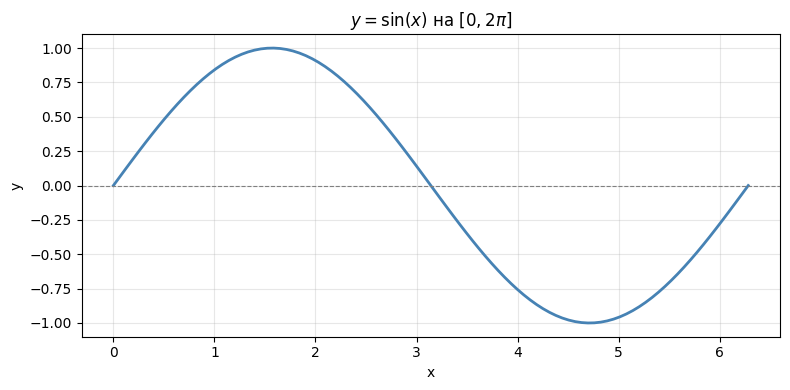

In [19]:
xs = np.linspace(0, 2 * np.pi, 100)

plt.figure(figsize=(8, 4))
plt.plot(xs, np.sin(xs), color="steelblue", linewidth=2)
plt.title(r"$y = \sin(x)$ на $[0, 2\pi]$")
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

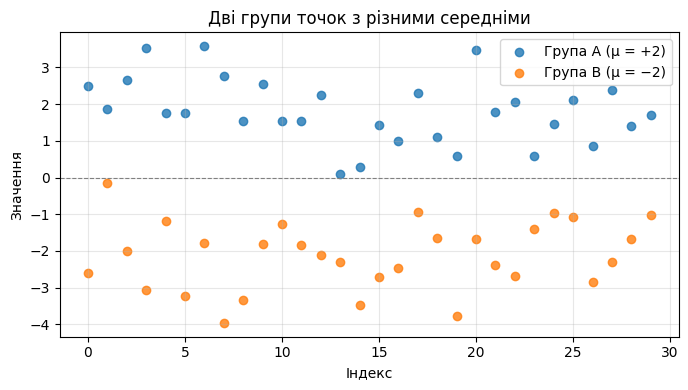

In [20]:
set_seed()
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.figure(figsize=(7, 4))
plt.scatter(range(30), group_a, color="C0", label="Група A (μ = +2)", alpha=0.8)
plt.scatter(range(30), group_b, color="C1", label="Група B (μ = −2)", alpha=0.8)
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Індекс")
plt.ylabel("Значення")
plt.title("Дві групи точок з різними середніми")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [21]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

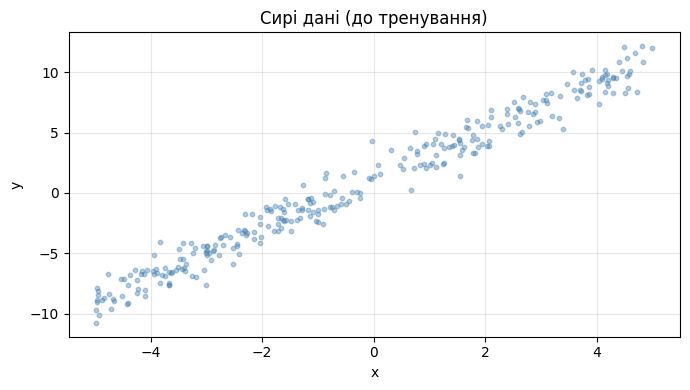

In [22]:
plt.figure(figsize=(7, 4))
plt.scatter(x1.numpy(), y1.numpy(), s=10, alpha=0.4, color="steelblue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [23]:
# Перемішуємо дані
perm = torch.randperm(TASK1_N)
x1 = x1[perm]
y1 = y1[perm]

# Розраховуємо межі сплітів
n_train = int(0.70 * TASK1_N)   # 210
n_val   = int(0.15 * TASK1_N)   # 45
# n_test = решта (45)

x_train1, y_train1 = x1[:n_train],              y1[:n_train]
x_val1,   y_val1   = x1[n_train:n_train+n_val], y1[n_train:n_train+n_val]
x_test1,  y_test1  = x1[n_train+n_val:],        y1[n_train+n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [24]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)
snapshots = []

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=52.999176  w=1.7073 (true 2.0)  b=-0.1046 (true 1.0)
epoch   30  loss=0.873840  w=2.0204 (true 2.0)  b=0.9961 (true 1.0)
epoch   60  loss=0.870761  w=2.0217 (true 2.0)  b=1.0441 (true 1.0)
epoch   90  loss=0.870755  w=2.0218 (true 2.0)  b=1.0462 (true 1.0)
epoch   99  loss=0.870755  w=2.0218 (true 2.0)  b=1.0462 (true 1.0)


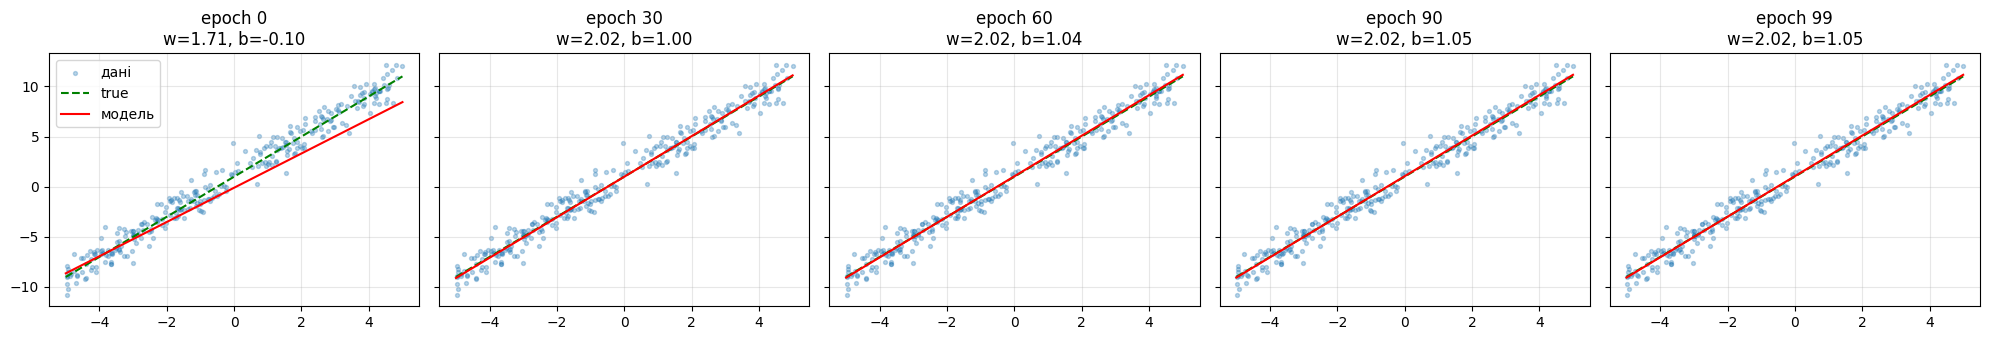

In [25]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Власний сценарій: **Години підготовки → Бал на іспиті**

Модель: $\text{score} = w \cdot \text{hours} + b + \varepsilon$

- $w = 4.5$ — кожна година підготовки дає приблизно 4.5 бали (правдоподібно для шкали 0–100)
- $b = 40.0$ — базовий бал без підготовки (студент щось знає із загального розвитку)
- $\varepsilon \sim \mathcal{N}(0, 5)$ — невеликий шум: різниця в настрої, здоров'ї тощо
- Діапазон: $x \in [0, 12]$ годин (реальна підготовка студента)


Датасет збережено: /content/drive/MyDrive/ai_systems/lab1/dataset.csv (200 рядків)
       hours_studied  exam_score
count         200.00      200.00
mean            5.84       66.94
std             3.44       16.11
min             0.04       35.31
25%             2.79       55.05
50%             5.61       66.38
75%             8.52       79.13
max            12.00       97.93


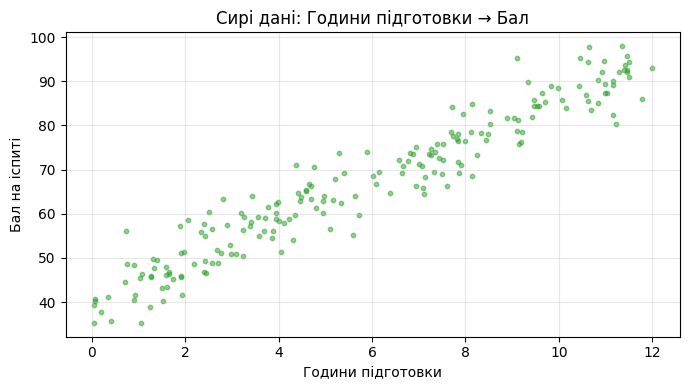

Спліт: train=140, val=30, test=30
epoch    0  train_loss=4494.1665  val_loss=447.8069  w=8.6222  b=0.3970
epoch  200  train_loss=71.5052  val_loss=59.1588  w=6.2661  b=27.0841
epoch  400  train_loss=26.3938  val_loss=22.7444  w=5.1025  b=36.0433
epoch  600  train_loss=21.2552  val_loss=19.0387  w=4.7098  b=39.0670
epoch  800  train_loss=20.6699  val_loss=18.7659  w=4.5773  b=40.0875
epoch 1000  train_loss=20.6033  val_loss=18.7852  w=4.5326  b=40.4319
epoch 1200  train_loss=20.5957  val_loss=18.8044  w=4.5175  b=40.5481
epoch 1400  train_loss=20.5948  val_loss=18.8123  w=4.5124  b=40.5874
epoch 1600  train_loss=20.5947  val_loss=18.8151  w=4.5106  b=40.6006
epoch 1800  train_loss=20.5947  val_loss=18.8161  w=4.5101  b=40.6051
epoch 1999  train_loss=20.5947  val_loss=18.8164  w=4.5099  b=40.6065

Навчені параметри: w=4.5099 (true 4.5), b=40.6065 (true 40.0)
Test MSE  = 16.8511
Test RMSE = 4.1050


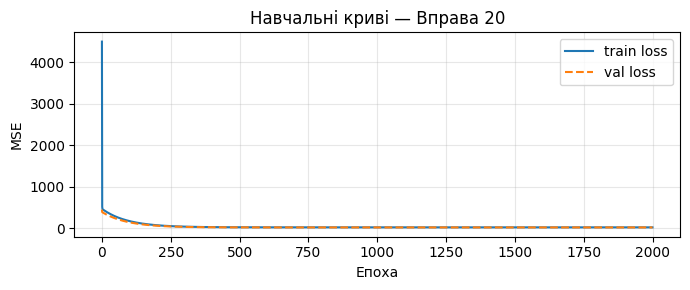

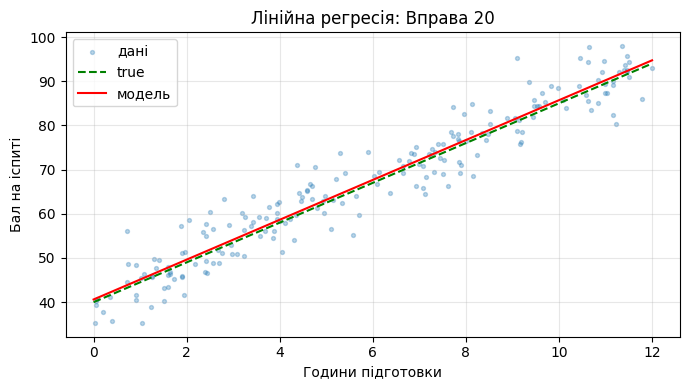

In [26]:
import os

STUDY_W = 4.5
STUDY_B = 40.0
STUDY_N = 200
STUDY_NOISE_STD = 5.0

set_seed()

# --- Генерація даних ---
hours = torch.empty(STUDY_N, 1).uniform_(0, 12)
noise_study = STUDY_NOISE_STD * torch.randn(STUDY_N, 1)
exam_score = STUDY_W * hours + STUDY_B + noise_study
# Обмежуємо бал діапазоном [0, 100]
exam_score = exam_score.clamp(0, 100)

# --- Збереження у CSV ---
df_study = pd.DataFrame({
    "hours_studied": hours.squeeze().numpy(),
    "exam_score":    exam_score.squeeze().numpy()
})

CSV_PATH = os.path.join(ARTIFACT_DIR, "dataset.csv") if 'ARTIFACT_DIR' in dir() else "dataset.csv"
df_study.to_csv(CSV_PATH, index=False)
print(f"Датасет збережено: {CSV_PATH} ({len(df_study)} рядків)")
print(df_study.describe().round(2))

# --- Scatter до тренування ---
plt.figure(figsize=(7, 4))
plt.scatter(hours.numpy(), exam_score.numpy(), s=10, alpha=0.5, color="C2")
plt.xlabel("Години підготовки")
plt.ylabel("Бал на іспиті")
plt.title("Сирі дані: Години підготовки → Бал")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Перевикористовувані функції для тренування

def train_test_split(x, y, train_frac=0.70, val_frac=0.15, seed=SEED):
    """Перемішати і розбити на train/val/test."""
    n = len(x)
    perm = torch.randperm(n)
    x, y = x[perm], y[perm]
    n_train = int(train_frac * n)
    n_val   = int(val_frac * n)
    return (
        x[:n_train],              y[:n_train],
        x[n_train:n_train+n_val], y[n_train:n_train+n_val],
        x[n_train+n_val:],        y[n_train+n_val:]
    )


def train_linear_model(x_train, y_train, x_val, y_val,
                        lr=0.01, epochs=200, verbose_every=40):
    """Навчити torch.nn.Linear і повернути модель та історію loss."""
    model = torch.nn.Linear(in_features=1, out_features=1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    history = {"train": [], "val": []}

    for epoch in range(epochs):
        # --- train ---
        model.train()
        optimizer.zero_grad()
        train_loss = loss_fn(model(x_train), y_train)
        train_loss.backward()
        optimizer.step()

        # --- val ---
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x_val), y_val)

        history["train"].append(train_loss.item())
        history["val"].append(val_loss.item())

        if verbose_every and (epoch % verbose_every == 0 or epoch == epochs - 1):
            print(f"epoch {epoch:4d}  train_loss={train_loss.item():.4f}  "
                  f"val_loss={val_loss.item():.4f}  "
                  f"w={model.weight.item():.4f}  b={model.bias.item():.4f}")

    return model, history


def evaluate_model(model, x_test, y_test):
    """Оцінити модель на тестовій вибірці (MSE і RMSE)."""
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test)
        mse = torch.nn.MSELoss()(y_pred, y_test).item()
    print(f"Test MSE  = {mse:.4f}")
    print(f"Test RMSE = {mse ** 0.5:.4f}")
    return mse


# --- Тренування ---
set_seed()
x_tr, y_tr, x_v, y_v, x_te, y_te = train_test_split(hours, exam_score)
print(f"Спліт: train={len(x_tr)}, val={len(x_v)}, test={len(x_te)}")

study_model, history = train_linear_model(x_tr, y_tr, x_v, y_v,
                                          lr=0.01, epochs=2000, verbose_every=200)

print(f"\nНавчені параметри: w={study_model.weight.item():.4f} (true {STUDY_W}),"
      f" b={study_model.bias.item():.4f} (true {STUDY_B})")

# --- Тест ---
evaluate_model(study_model, x_te, y_te)

# --- Loss-криві ---
plt.figure(figsize=(7, 3))
plt.plot(history["train"], label="train loss")
plt.plot(history["val"],   label="val loss",   linestyle="--")
plt.xlabel("Епоха"); plt.ylabel("MSE")
plt.title("Навчальні криві — Вправа 20")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Візуалізація: дані + навчена пряма ---
x_line_study = torch.linspace(0, 12, 100).unsqueeze(1)
with torch.no_grad():
    y_line_pred_study = study_model(x_line_study)
    y_line_true_study = STUDY_W * x_line_study + STUDY_B

plt.figure(figsize=(7, 4))
plt.scatter(hours.numpy(), exam_score.numpy(), s=8, alpha=0.3, label="дані")
plt.plot(x_line_study.numpy(), y_line_true_study.numpy(), "g--", label="true")
plt.plot(x_line_study.numpy(), y_line_pred_study.numpy(), "r-",  label="модель")
plt.xlabel("Години підготовки"); plt.ylabel("Бал на іспиті")
plt.title("Лінійна регресія: Вправа 20")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [27]:
# Зберігаємо натреновану модель
MODEL_PATH = os.path.join(ARTIFACT_DIR, "model.pt") if 'ARTIFACT_DIR' in dir() else "model.pt"
torch.save(study_model.state_dict(), MODEL_PATH)
print(f"Модель збережено: {MODEL_PATH}")

# Перевірка: завантажуємо назад і порівнюємо
loaded_model = torch.nn.Linear(in_features=1, out_features=1)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()
with torch.no_grad():
    test_input = torch.tensor([[5.0]])
    print(f"Перевірка: model(5 год) = {loaded_model(test_input).item():.2f} балів")


Модель збережено: /content/drive/MyDrive/ai_systems/lab1/model.pt
Перевірка: model(5 год) = 63.16 балів


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [28]:
!pip install -q gradio
import gradio as gr


In [29]:
MODEL_PATH = os.path.join(ARTIFACT_DIR, "model.pt") if 'ARTIFACT_DIR' in dir() else "model.pt"
inference_model = torch.nn.Linear(in_features=1, out_features=1)
inference_model.load_state_dict(torch.load(MODEL_PATH))
inference_model.eval()


def predict_score(hours_studied: float) -> str:
    """Передбачити бал на іспиті за кількістю годин підготовки."""
    with torch.no_grad():
        x = torch.tensor([[float(hours_studied)]])
        score = inference_model(x).item()
        score = max(0.0, min(100.0, score))
    return f"{score:.1f} / 100 балів"


demo = gr.Interface(
    fn=predict_score,
    inputs=gr.Slider(minimum=0, maximum=12, step=0.5, value=5,
                     label="Години підготовки до іспиту"),
    outputs=gr.Text(label="Передбачений бал на іспиті"),
    title="🎓 Передбачення балу за годинами підготовки",
    description=(
        f"Лінійна модель: score = {inference_model.weight.item():.2f} × hours "
        f"+ {inference_model.bias.item():.2f}\n"
        "Навчена на синтетичних даних (Вправа 20)."
    ),
    examples=[[0], [3], [6], [9], [12]],
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://252272c6cfc7fc3a02.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```